# Chinatown HEROS Project — Air Quality & Temperature Analysis

This notebook analyzes environmental monitoring data collected from **12 open-space sites** in Boston's Chinatown during the summer of 2023 (July 19 – August 23). We compare readings from low-cost community sensors against regulatory-grade reference monitors.

**Two research questions:**

1. **PM2.5:** How do Purple Air PM2.5 data at each of the 12 sites compare with the MassDEP FEM PM2.5 data in Chinatown and Nubian Square?
2. **Temperature:** How do Kestrel ambient temperature data at each of the 12 sites compare with the weather station at 35 Kneeland St and the MassDEP FEM monitor at Nubian Square?

---

### Data Sources

| Source | Instrument | Key Variable |
|---|---|---|
| **Purple Air** (12 sites) | Low-cost PM2.5 sensor | `pa_mean_pm2_5_atm_b_corr_2` — corrected PM2.5 (µg/m³) |
| **Kestrel** (12 sites) | Portable weather meter | `kes_mean_temp_f` — ambient temperature (°F) |
| **Weather Station** (35 Kneeland St) | Rooftop station | `mean_temp_out_f` — outdoor temp (°F) |
| **MassDEP FEM Chinatown** | Federal Equivalent Method | `dep_FEM_chinatown_pm2_5_ug_m3` — PM2.5 (µg/m³) |
| **MassDEP FEM Nubian Sq.** | Federal Equivalent Method | `dep_FEM_nubian_pm2_5_ug_m3`, `dep_FEM_nubian_temp_f` |

## 1 — Setup & Data Loading

We start by importing libraries and loading the HEROS dataset. The Excel file contains a single sheet with **48,123 rows** (10-minute interval readings across all 12 sites).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

# Nicer plots
plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.3})

In [ ]:
# !pip install openpyxl -q

In [4]:
# Load the HEROS dataset
df = pd.read_excel('data_HEROS.xlsx', sheet_name='Sheet 1')
df['date'] = pd.to_datetime(df['date'])

print(f'Shape: {df.shape}')
print(f'Date range: {df["date"].min()} to {df["date"].max()}')
print(f'\nColumns:\n{list(df.columns)}')
df.head(3)

Shape: (48123, 20)
Date range: 2023-07-19 16:40:00 to 2023-08-23 15:50:00

Columns:
['siteID', 'date', 'kes_mean_temp_f', 'kes_mean_wbgt_f', 'kes_mean_humid_pct', 'kes_mean_press_inHg', 'kes_mean_heat_f', 'kes_mean_dew_f', 'pa_mean_pm2_5_atm_b_corr_2', 'mean_temp_out_f', 'mean_out_hum_pct', 'mean_dew_pt_f', 'mean_wind_speed_mph', 'wind_direction_degrees_kr', 'mean_heat_index_f', 'mean_thw_index_f', 'dep_FEM_chinatown_pm2_5_ug_m3', 'dep_FEM_nubian_pm2_5_ug_m3', 'dep_FEM_nubian_temp_f', 'dep_FEM_nubian_humid_pct']


,siteID,date,kes_mean_temp_f,kes_mean_wbgt_f,kes_mean_humid_pct,kes_mean_press_inHg,kes_mean_heat_f,kes_mean_dew_f,pa_mean_pm2_5_atm_b_corr_2,mean_temp_out_f,mean_out_hum_pct,mean_dew_pt_f,mean_wind_speed_mph,wind_direction_degrees_kr,mean_heat_index_f,mean_thw_index_f,dep_FEM_chinatown_pm2_5_ug_m3,dep_FEM_nubian_pm2_5_ug_m3,dep_FEM_nubian_temp_f,dep_FEM_nubian_humid_pct
0,berkley,2023-07-19 19:00:00,84.6,67.1,40.6,29.95,84.4,58.0,15.140488,86.05,45.5,62.55,2.0,135.0,86.9,86.9,14.130508,13.12,82.976,46.28
1,berkley,2023-07-19 19:10:00,85.3,67.5,40.0,29.96,85.3,58.3,14.550256,85.60,42.5,60.20,3.0,315.0,85.6,85.6,13.132611,13.53,82.508,47.50
2,berkley,2023-07-19 19:20:00,82.9,66.9,43.7,29.95,82.2,58.6,14.998800,85.35,43.0,60.30,3.5,315.0,85.4,85.4,12.647859,13.55,82.166,48.49


### Identify the 12 open-space sites

Each row in the dataset is tagged with a `siteID`. Let's list all sites and confirm we have 12 community monitoring locations.

In [5]:
sites = sorted(df['siteID'].unique())
open_sites = [s for s in sites if 'dep' not in s.lower()]

# Pretty names for display
PRETTY = {
    'berkley': 'Berkley Comm. Garden', 'castle': 'Castle Square',
    'chin': 'Chin Park', 'dewey': 'Dewey Square',
    'eliotnorton': 'Eliot Norton Park', 'greenway': 'One Greenway',
    'lyndenboro': 'Lyndenboro', 'msh': 'Mary Soo Hoo',
    'oxford': 'Oxford Place Plaza', 'reggie': 'Reggie Wong Park',
    'taitung': 'Tai Tung Park', 'tufts': 'Tufts Comm. Garden',
}
pretty = lambda s: PRETTY.get(s, s)

print(f'{len(open_sites)} open-space sites:')
for s in open_sites:
    n = len(df[df['siteID'] == s])
    print(f'  {pretty(s):25s} — {n:,} observations')

12 open-space sites:
  Berkley Comm. Garden      — 2,445 observations
  Castle Square             — 4,881 observations
  Chin Park                 — 2,199 observations
  Dewey Square              — 4,903 observations
  Eliot Norton Park         — 3,888 observations
  One Greenway              — 4,893 observations
  Lyndenboro                — 4,786 observations
  Mary Soo Hoo              — 4,189 observations
  Oxford Place Plaza        — 2,879 observations
  Reggie Wong Park          — 4,126 observations
  Tai Tung Park             — 4,839 observations
  Tufts Comm. Garden        — 4,095 observations


---

## 2 — Question 1: PM2.5 Comparison

**How do Purple Air PM2.5 readings at each site compare with the MassDEP FEM monitors?**

### Why this comparison matters

PM2.5 (particulate matter ≤ 2.5 micrometers) is one of the most health-relevant air pollutants. These tiny particles penetrate deep into the lungs and enter the bloodstream, contributing to respiratory and cardiovascular disease. The EPA sets a 24-hour standard of **35 µg/m³** and an annual standard of **9.0 µg/m³**.

The scientific challenge is that **regulatory monitors are sparse** — MassDEP operates only a handful across the entire Boston metro area. Low-cost sensors like Purple Air can fill spatial gaps, but their accuracy must be validated against the regulatory "gold standard" before they can be trusted for public health decisions.

### The three columns we compare

| Column | Source | What it measures | Why we use it |
|---|---|---|---|
| `pa_mean_pm2_5_atm_b_corr_2` | **Purple Air** sensor at each open-space site | Corrected PM2.5 concentration (µg/m³), averaged over 10-min intervals. Uses a laser-scattering method with a humidity correction applied. | This is the **hyperlocal measurement** — one sensor per site, capturing neighborhood-level air quality that the sparse DEP network misses. |
| `dep_FEM_chinatown_pm2_5_ug_m3` | **MassDEP FEM** monitor in Chinatown (brick building next to Reggie Wong Park) | PM2.5 via Federal Equivalent Method (T640X analyzer), 10-min averages | This is the **local regulatory reference**. A FEM instrument meets strict EPA performance criteria for accuracy, precision, and calibration. It's the closest "ground truth" to the study area. |
| `dep_FEM_nubian_pm2_5_ug_m3` | **MassDEP FEM** monitor in Nubian Square (Roxbury) | Same FEM instrument and method, but located ~2 miles away | This is the **regional control**. By comparing Chinatown sites against a second FEM monitor outside the neighborhood, we can distinguish *sensor bias* (Purple Air reads high everywhere) from *real local pollution differences* (Chinatown genuinely has different air quality than Roxbury). |

### The scientific logic

The analysis follows a standard **sensor validation framework**:

1. **Bias assessment** — Compute the mean difference (Purple Air − DEP FEM). A consistent positive or negative offset indicates systematic sensor bias that can be corrected.
2. **Correlation analysis** — Compute Pearson's r to measure temporal agreement. High correlation (r > 0.9) means the sensor tracks the same pollution events as the FEM, even if absolute values differ.
3. **Spatial comparison** — If DEP Chinatown ≈ DEP Nubian, then PM2.5 is regionally uniform and any Purple Air deviation is likely sensor bias. If they differ, there may be genuine local sources.
4. **Diurnal patterns** — Examining how PM2.5 varies by hour of day reveals whether the sensor captures known atmospheric dynamics (e.g., nighttime inversions trapping pollution near the surface).

### 2.1 — Summary Statistics by Site

In [6]:
# Build a summary table: Purple Air stats per site + DEP reference means
pm_rows = []
for site in open_sites:
    sd = df[df['siteID'] == site]
    pa = sd['pa_mean_pm2_5_atm_b_corr_2'].dropna()
    ct = sd['dep_FEM_chinatown_pm2_5_ug_m3'].dropna()
    nu = sd['dep_FEM_nubian_pm2_5_ug_m3'].dropna()
    pm_rows.append({
        'Site': pretty(site),
        'N': len(pa),
        'PA Mean': round(pa.mean(), 2),
        'PA Median': round(pa.median(), 2),
        'PA Std': round(pa.std(), 2),
        'PA Min': round(pa.min(), 2),
        'PA Max': round(pa.max(), 2),
        'DEP CT Mean': round(ct.mean(), 2),
        'DEP Nub Mean': round(nu.mean(), 2),
        'Bias (PA−CT)': round(pa.mean() - ct.mean(), 2),
        'Bias (PA−Nub)': round(pa.mean() - nu.mean(), 2),
    })

pm_summary = pd.DataFrame(pm_rows)

# Style the table so positive bias is highlighted
pm_summary.style.background_gradient(
    subset=['Bias (PA−CT)', 'Bias (PA−Nub)'], cmap='RdYlGn_r', vmin=-1, vmax=3
).format(precision=2)

,Site,N,PA Mean,PA Median,PA Std,PA Min,PA Max,DEP CT Mean,DEP Nub Mean,Bias (PA−CT),Bias (PA−Nub)
0,Berkley Comm. Garden,2445,9.53,8.46,4.94,2.04,25.45,8.17,8.35,1.35,1.17
1,Castle Square,3909,7.90,6.67,5.58,-1.81,35.85,8.15,8.27,-0.25,-0.37
2,Chin Park,2196,10.51,9.98,5.97,0.22,28.90,8.70,8.79,1.82,1.72
3,Dewey Square,4901,9.68,8.67,5.56,-1.42,40.62,8.14,8.27,1.54,1.41
4,Eliot Norton Park,3886,9.30,8.35,4.89,0.93,23.49,7.96,8.12,1.33,1.18
5,One Greenway,4889,10.76,9.28,6.14,0.77,30.91,8.07,8.19,2.69,2.57
6,Lyndenboro,4778,10.71,9.51,5.75,1.32,42.66,8.41,8.55,2.30,2.16
7,Mary Soo Hoo,4187,9.05,8.34,4.58,-1.34,31.00,6.98,7.04,2.07,2.01
8,Oxford Place Plaza,2875,7.93,7.37,3.60,0.75,19.49,6.59,6.62,1.34,1.31
9,Reggie Wong Park,4126,8.34,7.06,4.98,0.05,28.92,7.64,7.73,0.70,0.61


**Interpretation:**

- The DEP FEM monitors averaged **~8.0 µg/m³** in both Chinatown and Nubian Square.
- **11 of 12 Purple Air sites read higher** than the DEP references, with a positive bias of +0.7 to +2.7 µg/m³. The only exception is **Castle Square** (−0.25 µg/m³), which read slightly *lower*.
- The largest overestimates came from **One Greenway (+2.69)**, **Lyndenboro (+2.30)**, and **Mary Soo Hoo (+2.07)**.
- This positive bias is well-documented in the literature for Purple Air sensors, even after applying correction factors.

### 2.2 — PM2.5 Distribution: Boxplot Comparison

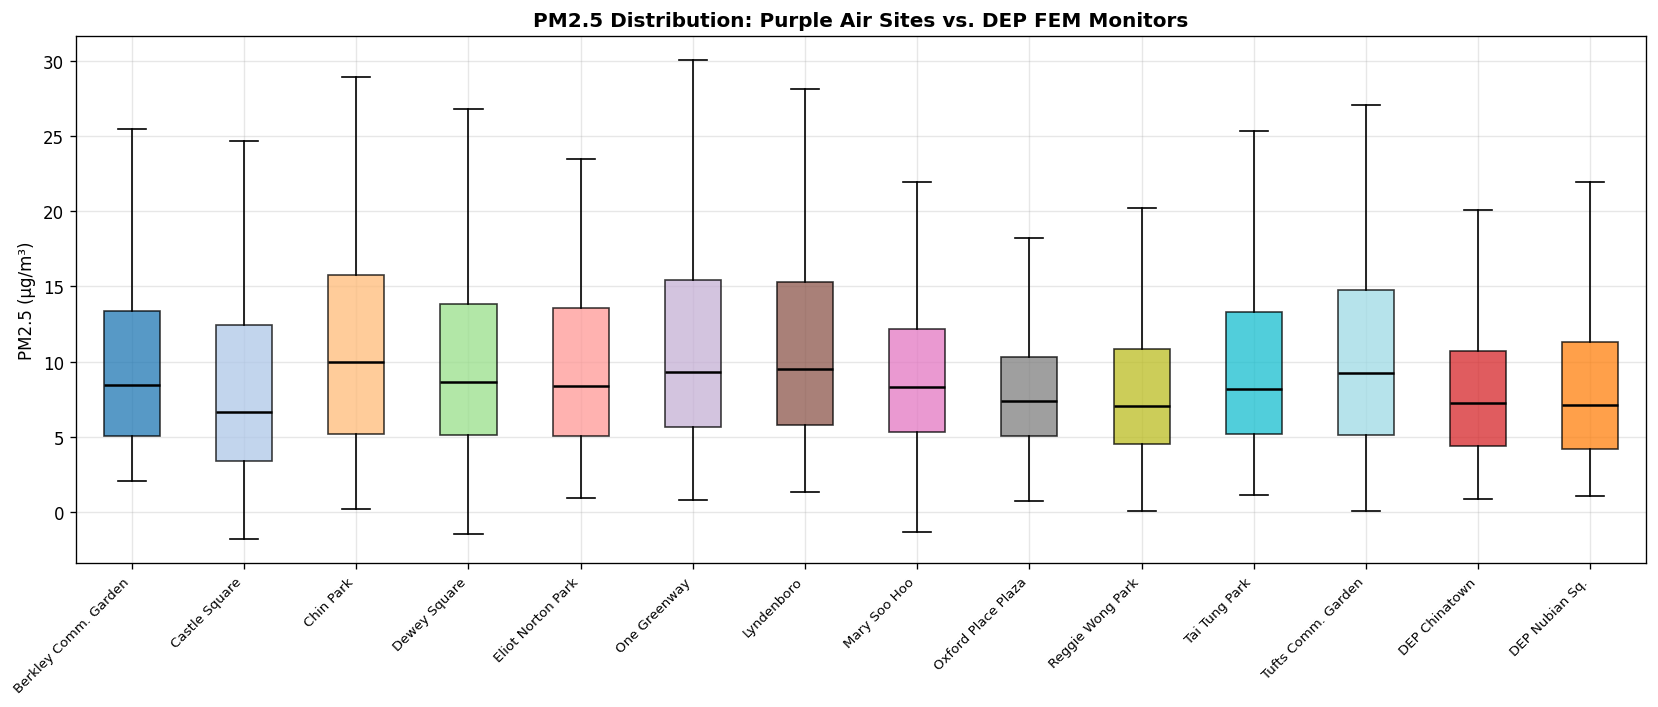

In [7]:
# Prepare boxplot data: 12 Purple Air sites + 2 DEP monitors
box_data = [df.loc[df['siteID'] == s, 'pa_mean_pm2_5_atm_b_corr_2'].dropna().values
            for s in open_sites]
box_data += [
    df['dep_FEM_chinatown_pm2_5_ug_m3'].dropna().values,
    df['dep_FEM_nubian_pm2_5_ug_m3'].dropna().values,
]
labels = [pretty(s) for s in open_sites] + ['DEP Chinatown', 'DEP Nubian Sq.']

# Color coding: site colors + red/orange for DEP
colors = list(plt.cm.tab20(np.linspace(0, 1, len(open_sites))))
colors += [(0.84, 0.15, 0.16, 0.8), (1.0, 0.50, 0.05, 0.8)]  # red, orange

fig, ax = plt.subplots(figsize=(14, 6))
bp = ax.boxplot(box_data, patch_artist=True, showfliers=False,
                medianprops=dict(color='black', linewidth=1.5))
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.75)

ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('PM2.5 (µg/m³)')
ax.set_title('PM2.5 Distribution: Purple Air Sites vs. DEP FEM Monitors', fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:** The boxplot shows that most Purple Air sites have **higher medians** and **wider interquartile ranges** than the two DEP FEM monitors (shown in red/orange on the right). Sites like One Greenway, Lyndenboro, and Chin Park stand out with notably elevated distributions. The DEP monitors show a tighter, more consistent range.

This makes sense — Purple Air sensors are located at ground level in open spaces with varied local conditions, while the DEP FEM monitors are at fixed installations designed for regulatory-grade measurement.

### 2.3 — Hourly PM2.5 Time Series

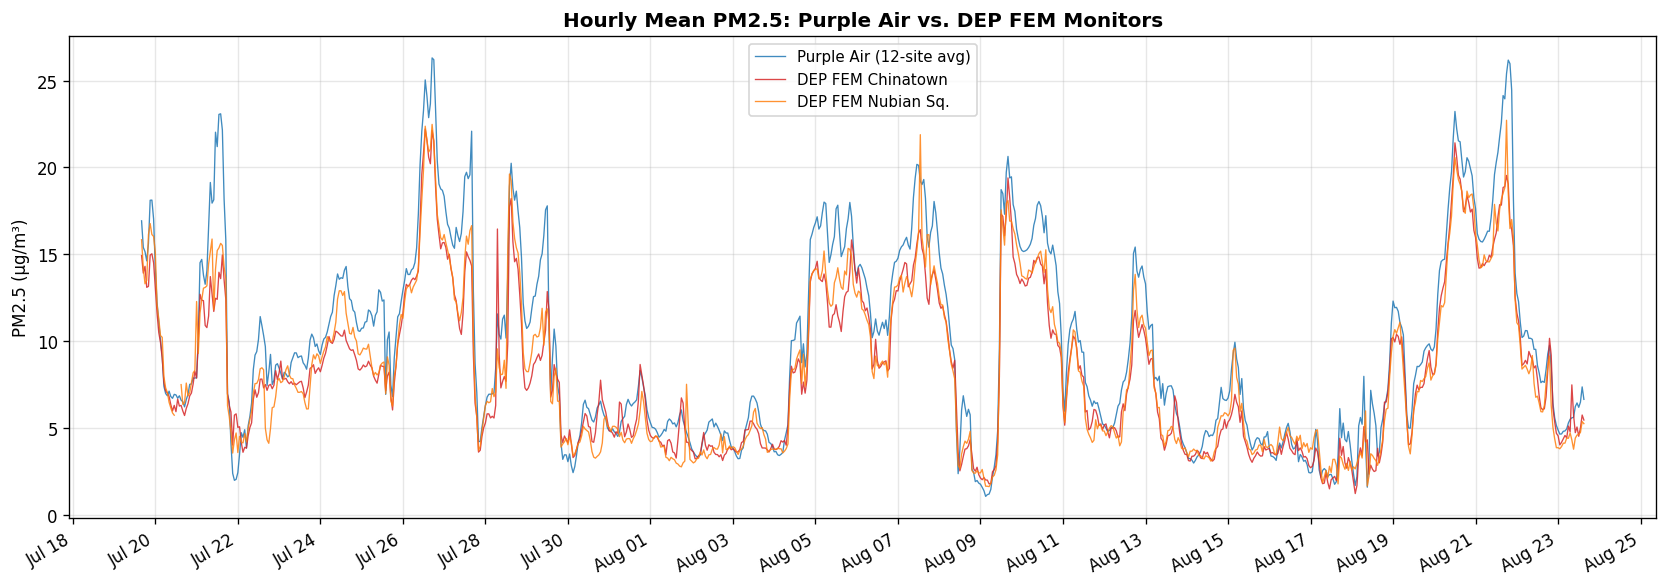

In [8]:
# Aggregate all sites to hourly averages
hourly_pm = df.set_index('date').groupby(pd.Grouper(freq='1h')).agg(
    pa_avg=('pa_mean_pm2_5_atm_b_corr_2', 'mean'),
    dep_ct=('dep_FEM_chinatown_pm2_5_ug_m3', 'mean'),
    dep_nu=('dep_FEM_nubian_pm2_5_ug_m3', 'mean'),
).dropna(how='all')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(hourly_pm.index, hourly_pm['pa_avg'], label='Purple Air (12-site avg)',
        linewidth=0.8, alpha=0.85, color='#1f77b4')
ax.plot(hourly_pm.index, hourly_pm['dep_ct'], label='DEP FEM Chinatown',
        linewidth=0.8, alpha=0.85, color='#d62728')
ax.plot(hourly_pm.index, hourly_pm['dep_nu'], label='DEP FEM Nubian Sq.',
        linewidth=0.8, alpha=0.85, color='#ff7f0e')

ax.set_ylabel('PM2.5 (µg/m³)')
ax.set_title('Hourly Mean PM2.5: Purple Air vs. DEP FEM Monitors', fontweight='bold')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

**Interpretation:** All three traces track the same pollution events — note the large spike around **July 26–28** and several smaller episodes in August. The Purple Air average (blue) consistently rides **above** the DEP lines, visually confirming the systematic positive bias. Critically, the *timing and shape* of peaks/troughs match closely, which means Purple Air is a **reliable relative indicator** of PM2.5 trends, even if the absolute values differ.

### 2.4 — Mean PM2.5 by Site (Bar Comparison)

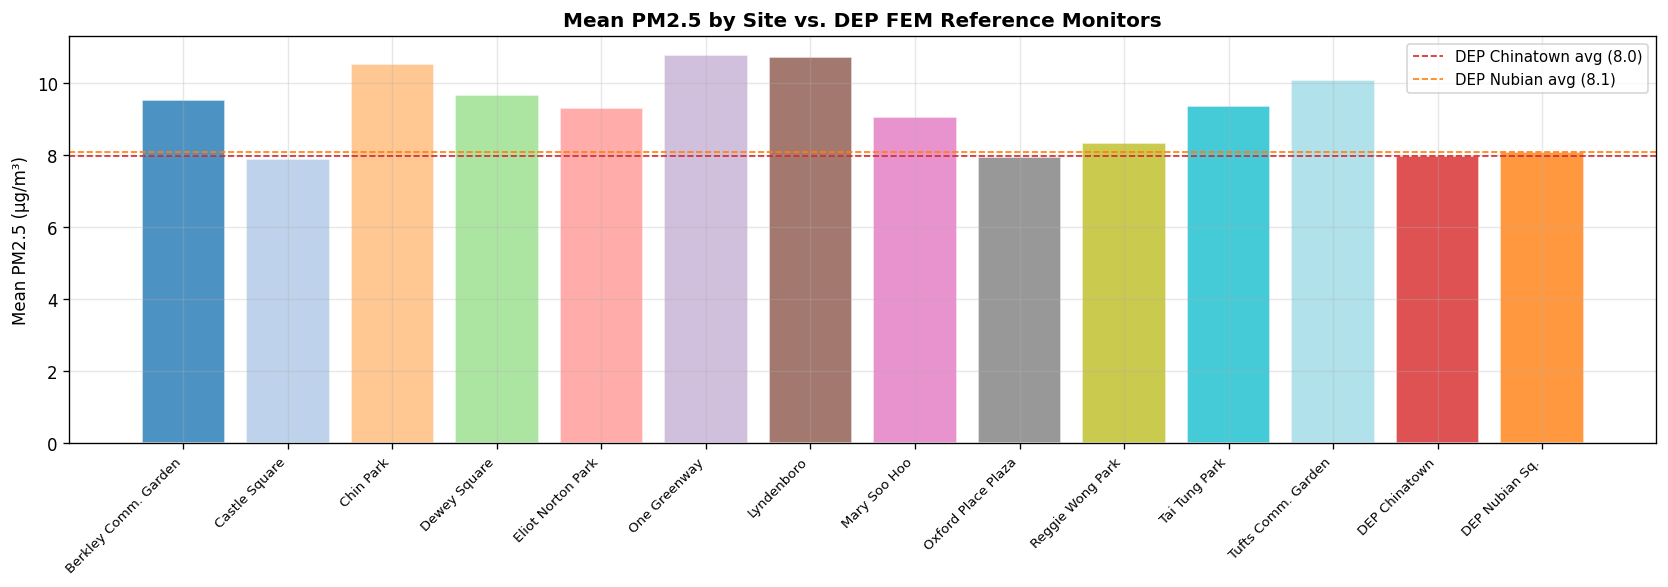

In [9]:
# Compute mean PM2.5 per site + DEP reference values
means = [df.loc[df['siteID'] == s, 'pa_mean_pm2_5_atm_b_corr_2'].mean() for s in open_sites]
dep_ct_mean = df['dep_FEM_chinatown_pm2_5_ug_m3'].mean()
dep_nu_mean = df['dep_FEM_nubian_pm2_5_ug_m3'].mean()
means += [dep_ct_mean, dep_nu_mean]

bar_labels = [pretty(s) for s in open_sites] + ['DEP Chinatown', 'DEP Nubian Sq.']
bar_colors = list(plt.cm.tab20(np.linspace(0, 1, len(open_sites)))) + ['#d62728', '#ff7f0e']

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(len(means)), means, color=bar_colors, alpha=0.8, edgecolor='white')
ax.axhline(dep_ct_mean, color='#d62728', ls='--', lw=1,
           label=f'DEP Chinatown avg ({dep_ct_mean:.1f})')
ax.axhline(dep_nu_mean, color='#ff7f0e', ls='--', lw=1,
           label=f'DEP Nubian avg ({dep_nu_mean:.1f})')

ax.set_xticks(range(len(means)))
ax.set_xticklabels(bar_labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Mean PM2.5 (µg/m³)')
ax.set_title('Mean PM2.5 by Site vs. DEP FEM Reference Monitors', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

**Interpretation:** The dashed lines mark the DEP FEM averages (~8.0 µg/m³). Every bar except Castle Square exceeds both reference lines. **One Greenway** and **Lyndenboro** have the highest mean PM2.5 (~10.7 µg/m³), while **Castle Square** and **Oxford Place Plaza** are closest to the DEP values.

This ~3 µg/m³ spread across sites suggests that **local factors** (traffic proximity, building canyoning, vegetation) influence PM2.5 concentrations at the neighborhood scale.

### 2.5 — Correlation: Purple Air vs. DEP FEM (Site-Level Scatterplots)

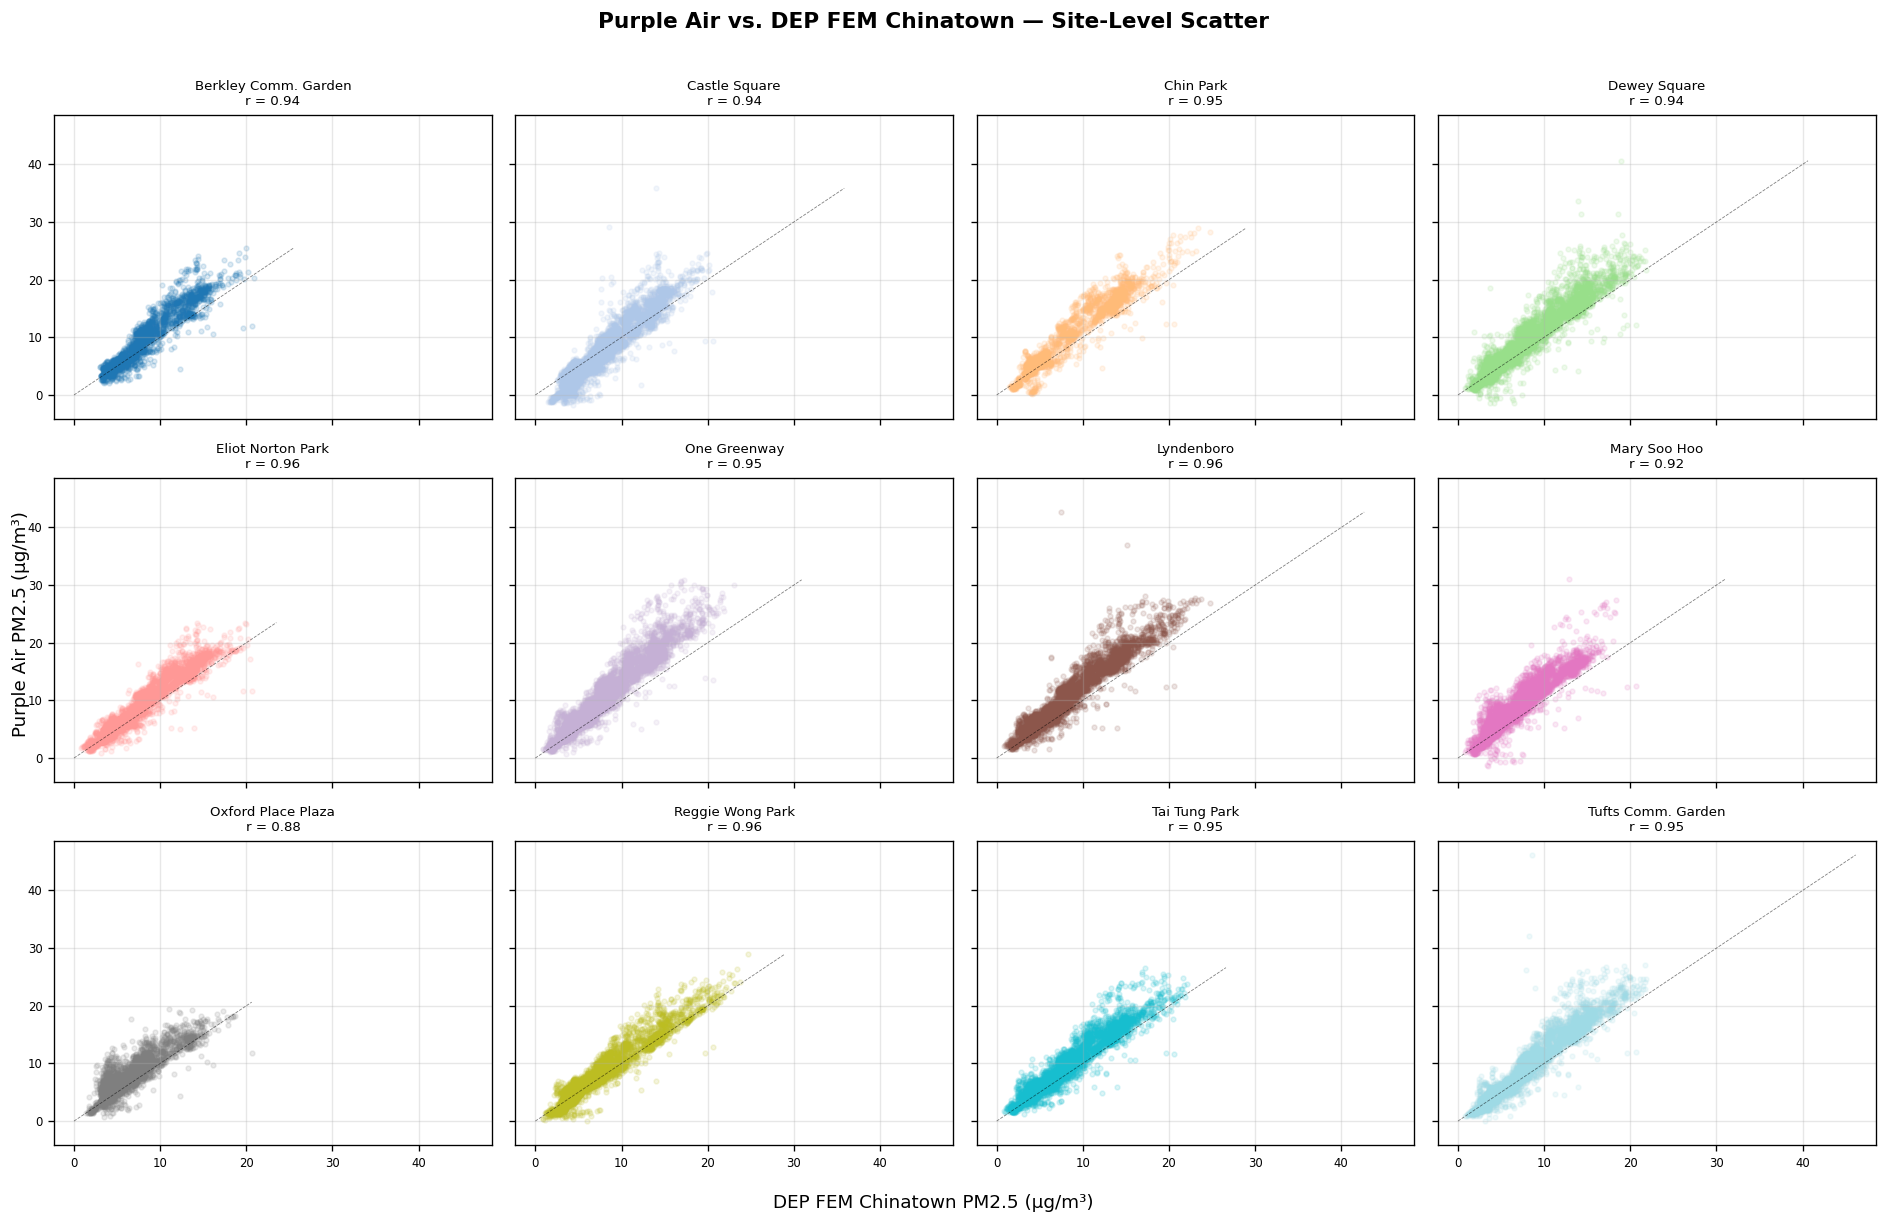

In [10]:
# 12-panel scatter: Purple Air PM2.5 (y) vs DEP Chinatown PM2.5 (x)
site_colors = plt.cm.tab20(np.linspace(0, 1, len(open_sites)))

fig, axes = plt.subplots(3, 4, figsize=(16, 10), sharex=True, sharey=True)
for i, site in enumerate(open_sites):
    ax = axes.flat[i]
    sd = df[df['siteID'] == site][[
        'pa_mean_pm2_5_atm_b_corr_2', 'dep_FEM_chinatown_pm2_5_ug_m3'
    ]].dropna()

    ax.scatter(sd['dep_FEM_chinatown_pm2_5_ug_m3'],
              sd['pa_mean_pm2_5_atm_b_corr_2'],
              alpha=0.15, s=8, color=site_colors[i])

    r = sd['pa_mean_pm2_5_atm_b_corr_2'].corr(sd['dep_FEM_chinatown_pm2_5_ug_m3'])
    ax.set_title(f'{pretty(site)}\nr = {r:.2f}', fontsize=8)

    # 1:1 reference line
    lim = max(sd.max())
    ax.plot([0, lim], [0, lim], 'k--', lw=0.5, alpha=0.5)
    ax.tick_params(labelsize=7)

fig.supxlabel('DEP FEM Chinatown PM2.5 (µg/m³)', fontsize=11)
fig.supylabel('Purple Air PM2.5 (µg/m³)', fontsize=11)
fig.suptitle('Purple Air vs. DEP FEM Chinatown — Site-Level Scatter',
             fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Interpretation:** Each panel plots a site's Purple Air readings against the concurrent DEP Chinatown readings. The dashed line is the **1:1 reference** — points above it mean Purple Air reads higher.

Key observations:
- **All correlations are r ≥ 0.88**, with most above 0.94. This is excellent.
- Points consistently cluster **above the 1:1 line**, confirming the positive bias.
- **Oxford Place Plaza** has the weakest correlation (r = 0.88), possibly due to its more sheltered urban setting.

### 2.6 — Correlation Summary Table

In [11]:
# Compute Pearson r for each site vs both DEP monitors
corr_rows = []
for site in open_sites:
    sd = df[df['siteID'] == site][[
        'pa_mean_pm2_5_atm_b_corr_2',
        'dep_FEM_chinatown_pm2_5_ug_m3',
        'dep_FEM_nubian_pm2_5_ug_m3'
    ]].dropna()
    corr_rows.append({
        'Site': pretty(site),
        'r (vs DEP Chinatown)': round(sd['pa_mean_pm2_5_atm_b_corr_2'].corr(
            sd['dep_FEM_chinatown_pm2_5_ug_m3']), 3),
        'r (vs DEP Nubian)': round(sd['pa_mean_pm2_5_atm_b_corr_2'].corr(
            sd['dep_FEM_nubian_pm2_5_ug_m3']), 3),
    })

corr_df = pd.DataFrame(corr_rows)
corr_df.style.background_gradient(subset=['r (vs DEP Chinatown)', 'r (vs DEP Nubian)'],
                                   cmap='Greens', vmin=0.85, vmax=1.0)

,Site,r (vs DEP Chinatown),r (vs DEP Nubian)
0,Berkley Comm. Garden,0.942000,0.961000
1,Castle Square,0.938000,0.944000
2,Chin Park,0.954000,0.959000
3,Dewey Square,0.942000,0.942000
4,Eliot Norton Park,0.956000,0.963000
5,One Greenway,0.953000,0.956000
6,Lyndenboro,0.955000,0.963000
7,Mary Soo Hoo,0.921000,0.915000
8,Oxford Place Plaza,0.881000,0.882000
9,Reggie Wong Park,0.957000,0.950000


All correlations exceed **r = 0.88**, meaning the Purple Air sensors capture the same temporal pollution patterns as the regulatory-grade DEP monitors — the sensors are tracking real air quality variations, not just noise.

### 2.7 — Diurnal PM2.5 Pattern

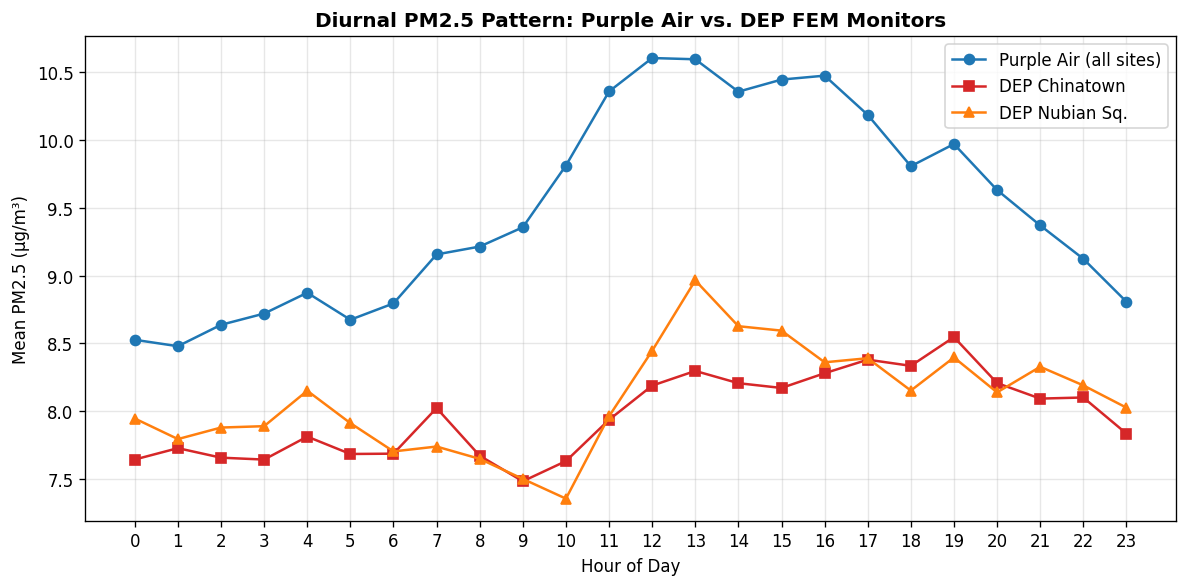

In [12]:
# Average PM2.5 by hour of day
df['hour'] = df['date'].dt.hour

diurnal_pm = df.groupby('hour').agg(
    pa=('pa_mean_pm2_5_atm_b_corr_2', 'mean'),
    dep_ct=('dep_FEM_chinatown_pm2_5_ug_m3', 'mean'),
    dep_nu=('dep_FEM_nubian_pm2_5_ug_m3', 'mean'),
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(diurnal_pm.index, diurnal_pm['pa'], 'o-',
        label='Purple Air (all sites)', color='#1f77b4')
ax.plot(diurnal_pm.index, diurnal_pm['dep_ct'], 's-',
        label='DEP Chinatown', color='#d62728')
ax.plot(diurnal_pm.index, diurnal_pm['dep_nu'], '^-',
        label='DEP Nubian Sq.', color='#ff7f0e')

ax.set_xlabel('Hour of Day')
ax.set_ylabel('Mean PM2.5 (µg/m³)')
ax.set_title('Diurnal PM2.5 Pattern: Purple Air vs. DEP FEM Monitors', fontweight='bold')
ax.legend()
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

**Interpretation:** PM2.5 tends to peak in the **late evening / early morning** and dip in the **afternoon**. This pattern is consistent across all three sources and is driven by the atmospheric boundary layer — at night, cooler air traps pollutants near the surface, while daytime heating promotes vertical mixing and dispersal.

The Purple Air trace runs a few µg/m³ higher throughout, maintaining the same positive offset around the clock.

---

## 3 — Question 2: Temperature Comparison

**How do Kestrel ambient temperatures at each site compare with the 35 Kneeland St weather station and the DEP Nubian Square monitor?**

### Why this comparison matters

Ambient temperature is the primary driver of **heat stress** — a growing public health concern in urban areas. During heat waves, outdoor temperatures can vary by several degrees over short distances depending on local features (shade, pavement, vegetation, wind exposure). These differences determine whether an open space is a **heat refuge** or a **heat trap** for residents seeking relief.

Understanding micro-scale temperature variation across Chinatown's open spaces requires sensors at each site — but those sensors need to be validated against established references to ensure the observed differences are real and not instrument error.

### The three columns we compare

| Column | Source | What it measures | Why we use it |
|---|---|---|---|
| `kes_mean_temp_f` | **Kestrel** portable weather meter at each open-space site | Ambient air temperature (°F), averaged over 10-min intervals. Kestrel sensors are research-grade handheld instruments commonly used in occupational and environmental health studies. | This is the **hyperlocal measurement** — one per site, placed at pedestrian level in each open space. It captures the microclimate that people actually experience. |
| `mean_temp_out_f` | **Weather Station** on the rooftop of 35 Kneeland Street (Chinatown) | Outdoor temperature (°F) from a Davis-type automated weather station, 10-min averages | This is the **local meteorological reference**. However, it's on a **rooftop**, which means it experiences different wind patterns, solar radiation, and heat radiation from building surfaces than ground-level sites. This is an important caveat when interpreting correlation results. |
| `dep_FEM_nubian_temp_f` | **MassDEP FEM** monitor at Nubian Square (Roxbury) | Ambient temperature (°F) from the T640X monitor's integrated temperature sensor | This is the **regional reference**. Located ~2 miles away in Roxbury, it provides a second independent temperature reading. Comparing against both references helps us separate *instrument differences* from *real microclimate variation*. |

### The scientific logic

The analysis follows a **sensor intercomparison approach** used in urban heat island (UHI) research:

1. **Bias assessment** — Compute Kestrel − Reference for each site. Small, consistent offsets (< ±2°F) indicate the sensors are well-calibrated. Larger or variable offsets could indicate instrument drift or genuine microclimate effects.
2. **Correlation analysis** — High correlation means the site sensor tracks the same weather-driven temperature swings as the reference. We expect temperature correlations to be driven primarily by regional weather (cold fronts, heat waves) with small local deviations from shade, wind, and surface type.
3. **Rooftop vs. ground-level caveat** — The 35 Kneeland station is on a rooftop, so we expect **weaker correlation** with ground-level Kestrel sensors due to differences in wind exposure, radiative cooling at night, and heat absorption from the roof surface. The DEP Nubian monitor should correlate better if its sensor is closer to ground level.
4. **Diurnal patterns** — Urban heat island effects are typically strongest at **night** (buildings and pavement release stored heat), so we check whether Kestrel sites show different nighttime cooling rates than the references.
5. **Site-to-site variation** — Even small temperature differences (1–2°F) across sites can indicate meaningful microclimate effects from tree canopy, impervious surfaces, or building geometry — factors that inform urban planning and heat mitigation strategies.

### 3.1 — Summary Statistics by Site

In [13]:
# Build temperature summary table
temp_rows = []
for site in open_sites:
    sd = df[df['siteID'] == site]
    kes = sd['kes_mean_temp_f'].dropna()
    ws  = sd['mean_temp_out_f'].dropna()
    nu  = sd['dep_FEM_nubian_temp_f'].dropna()
    temp_rows.append({
        'Site': pretty(site),
        'N': len(kes),
        'Kestrel Mean (°F)': round(kes.mean(), 2),
        'Kestrel Median': round(kes.median(), 2),
        'Kestrel Std': round(kes.std(), 2),
        'WS 35Kn Mean': round(ws.mean(), 2),
        'DEP Nub Mean': round(nu.mean(), 2),
        'Kes − WS (°F)': round(kes.mean() - ws.mean(), 2),
        'Kes − Nub (°F)': round(kes.mean() - nu.mean(), 2),
    })

temp_summary = pd.DataFrame(temp_rows)
temp_summary.style.background_gradient(
    subset=['Kes − WS (°F)', 'Kes − Nub (°F)'], cmap='coolwarm', vmin=-2, vmax=2
).format(precision=2)

,Site,N,Kestrel Mean (°F),Kestrel Median,Kestrel Std,WS 35Kn Mean,DEP Nub Mean,Kes − WS (°F),Kes − Nub (°F)
0,Berkley Comm. Garden,2445,74.41,74.10,6.72,74.84,75.33,-0.43,-0.93
1,Castle Square,3918,75.31,74.40,6.89,74.07,74.73,1.24,0.58
2,Chin Park,2199,75.03,74.38,6.43,74.73,75.28,0.30,-0.26
3,Dewey Square,4903,74.57,73.80,6.20,74.04,74.75,0.53,-0.19
4,Eliot Norton Park,3132,73.93,73.35,6.25,74.62,75.36,-0.69,-1.43
5,One Greenway,4887,74.50,73.80,6.36,73.96,74.66,0.54,-0.17
6,Lyndenboro,4786,74.39,73.50,6.47,74.39,75.17,-0.01,-0.78
7,Mary Soo Hoo,4189,73.91,73.30,5.81,73.52,73.81,0.40,0.11
8,Oxford Place Plaza,2879,74.96,74.70,5.62,73.91,74.24,1.05,0.73
9,Reggie Wong Park,4126,74.68,73.90,6.97,73.95,74.78,0.72,-0.11


**Interpretation:**

- Temperature differences are **very small** — all within ±1.5°F of both reference monitors.
- **Castle Square** was the warmest site (75.31°F mean), likely reflecting local urban heat effects (impervious surfaces, reduced canopy).
- **Eliot Norton Park** and **Mary Soo Hoo** were the coolest (~73.9°F), possibly benefiting from more green space.
- The 35 Kneeland St weather station averaged **74.11°F** and the DEP Nubian monitor **74.77°F**.

### 3.2 — Temperature Distribution: Boxplot Comparison

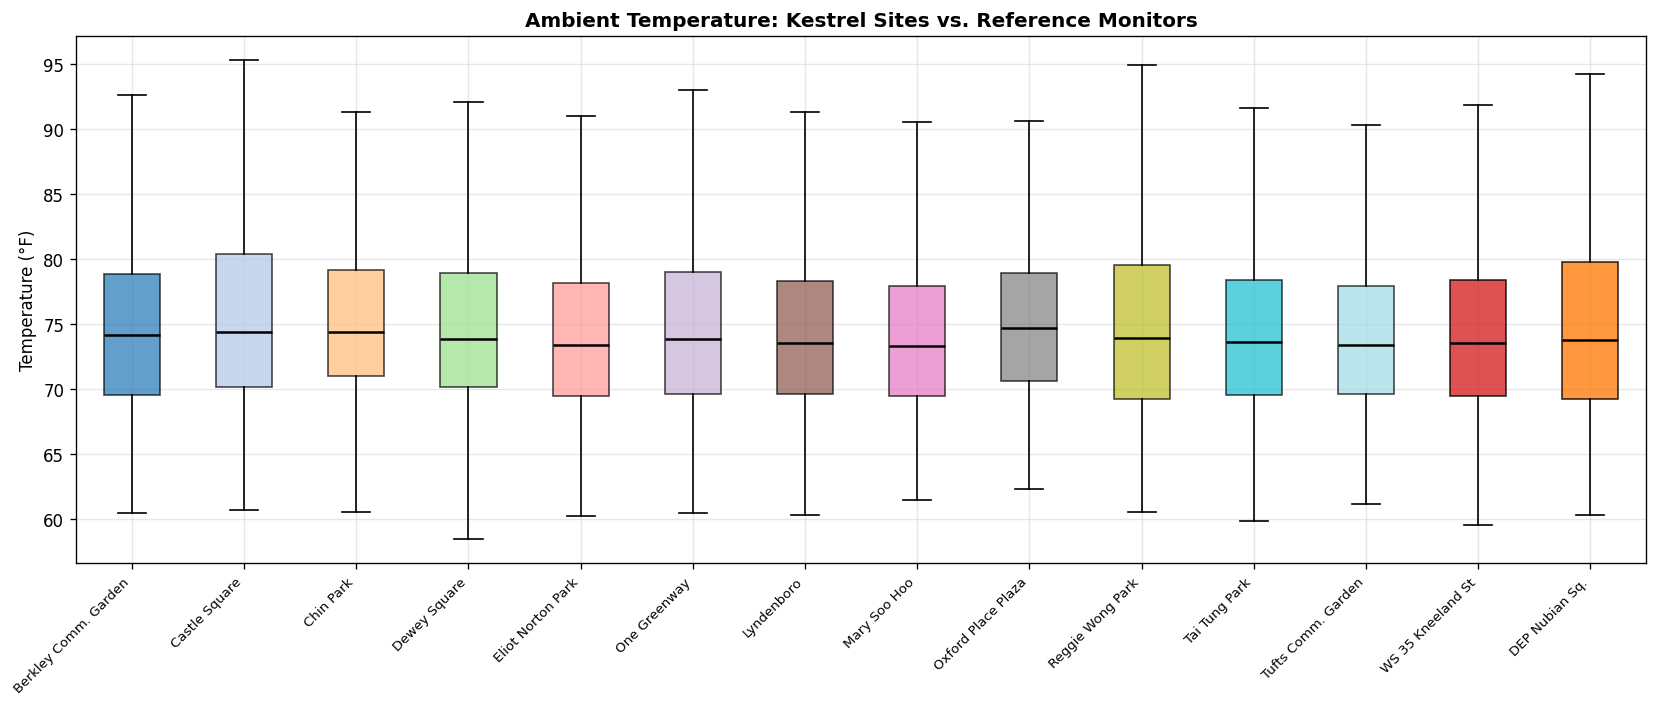

In [14]:
# Boxplot: 12 Kestrel sites + weather station + DEP Nubian
box_data_t = [df.loc[df['siteID'] == s, 'kes_mean_temp_f'].dropna().values
              for s in open_sites]
box_data_t += [
    df['mean_temp_out_f'].dropna().values,
    df['dep_FEM_nubian_temp_f'].dropna().values,
]
labels_t = [pretty(s) for s in open_sites] + ['WS 35 Kneeland St', 'DEP Nubian Sq.']

fig, ax = plt.subplots(figsize=(14, 6))
bp = ax.boxplot(box_data_t, patch_artist=True, showfliers=False,
                medianprops=dict(color='black', linewidth=1.5))
for i, patch in enumerate(bp['boxes']):
    if i < len(open_sites):
        patch.set_facecolor(site_colors[i])
        patch.set_alpha(0.7)
    elif i == len(open_sites):
        patch.set_facecolor('#d62728'); patch.set_alpha(0.8)
    else:
        patch.set_facecolor('#ff7f0e'); patch.set_alpha(0.8)

ax.set_xticklabels(labels_t, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Temperature (°F)')
ax.set_title('Ambient Temperature: Kestrel Sites vs. Reference Monitors', fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:** All 12 Kestrel sites show remarkably similar temperature distributions, with medians clustered around 73–75°F. The reference monitors (red, orange) overlap completely with the site data. Castle Square has a slightly higher upper quartile. Unlike PM2.5, temperature is dominated by **regional weather** with only modest microclimate variation between sites.

### 3.3 — Hourly Temperature Time Series

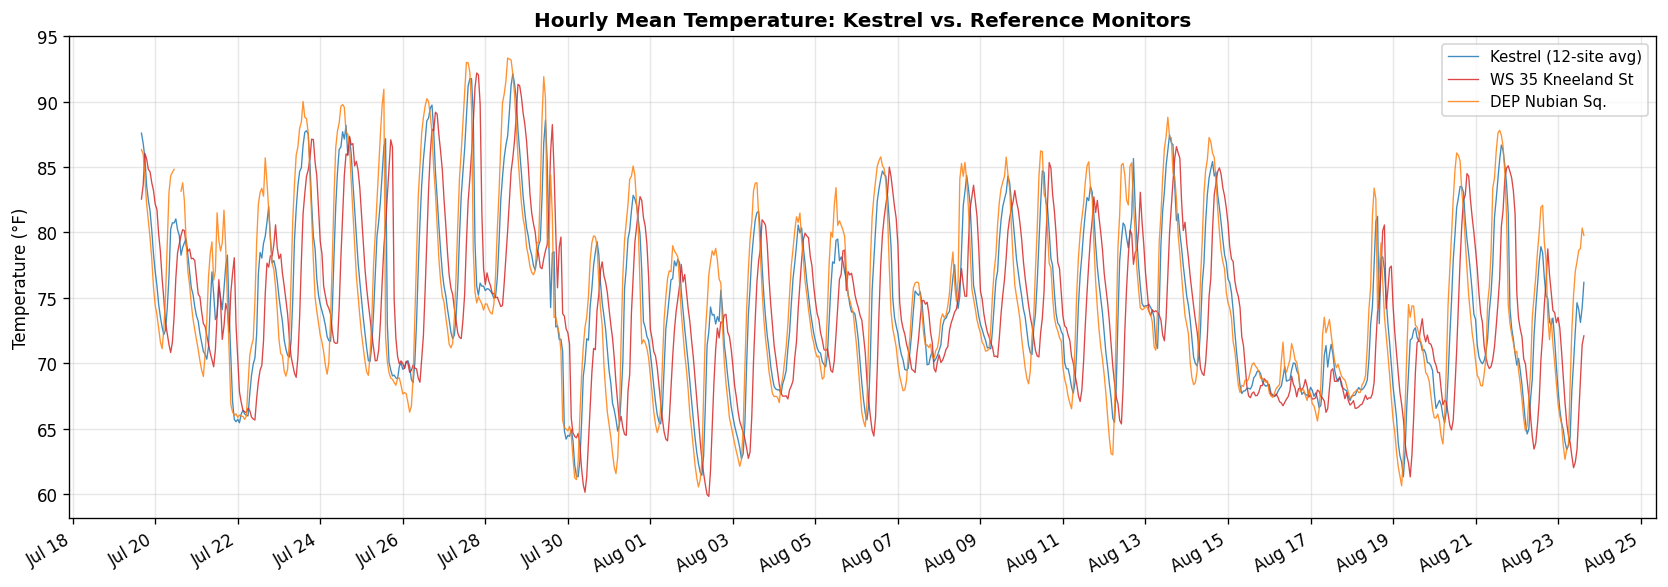

In [15]:
# Aggregate hourly temperature
hourly_t = df.set_index('date').groupby(pd.Grouper(freq='1h')).agg(
    kes_avg=('kes_mean_temp_f', 'mean'),
    ws=('mean_temp_out_f', 'mean'),
    dep_nu=('dep_FEM_nubian_temp_f', 'mean'),
).dropna(how='all')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(hourly_t.index, hourly_t['kes_avg'], label='Kestrel (12-site avg)',
        linewidth=0.8, alpha=0.85, color='#1f77b4')
ax.plot(hourly_t.index, hourly_t['ws'], label='WS 35 Kneeland St',
        linewidth=0.8, alpha=0.85, color='#d62728')
ax.plot(hourly_t.index, hourly_t['dep_nu'], label='DEP Nubian Sq.',
        linewidth=0.8, alpha=0.85, color='#ff7f0e')

ax.set_ylabel('Temperature (°F)')
ax.set_title('Hourly Mean Temperature: Kestrel vs. Reference Monitors', fontweight='bold')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

**Interpretation:** All three sources follow the same multi-day weather pattern. The late-July heat wave (**Jul 26–29**) is clearly visible, with all monitors exceeding 90°F. The three traces overlap closely, confirming that Kestrel sensors reliably capture ambient temperature dynamics.

### 3.4 — Mean Temperature by Site (Bar Comparison)

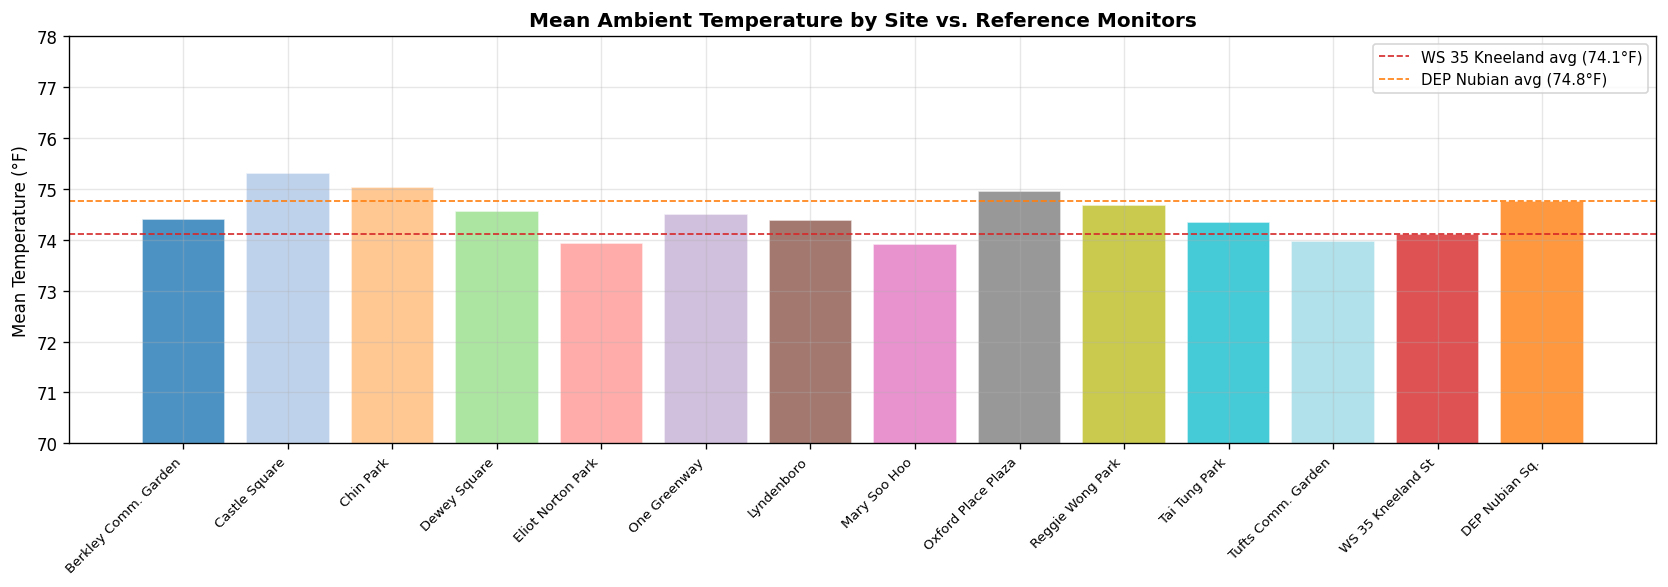

In [16]:
# Bar chart of mean temperature per site
t_means = [df.loc[df['siteID'] == s, 'kes_mean_temp_f'].mean() for s in open_sites]
ws_mean = df['mean_temp_out_f'].mean()
nu_mean = df['dep_FEM_nubian_temp_f'].mean()
t_means += [ws_mean, nu_mean]

bar_labels_t = [pretty(s) for s in open_sites] + ['WS 35 Kneeland St', 'DEP Nubian Sq.']
bar_colors_t = list(plt.cm.tab20(np.linspace(0, 1, len(open_sites)))) + ['#d62728', '#ff7f0e']

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(len(t_means)), t_means, color=bar_colors_t, alpha=0.8, edgecolor='white')
ax.axhline(ws_mean, color='#d62728', ls='--', lw=1,
           label=f'WS 35 Kneeland avg ({ws_mean:.1f}°F)')
ax.axhline(nu_mean, color='#ff7f0e', ls='--', lw=1,
           label=f'DEP Nubian avg ({nu_mean:.1f}°F)')

ax.set_xticks(range(len(t_means)))
ax.set_xticklabels(bar_labels_t, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Mean Temperature (°F)')
ax.set_title('Mean Ambient Temperature by Site vs. Reference Monitors', fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(70, 78)  # zoom in to see differences
plt.tight_layout()
plt.show()

**Interpretation:** With the y-axis zoomed in (70–78°F), we can see the small but real differences between sites. All sites cluster tightly around the reference averages (dashed lines). Castle Square and Chin Park trend slightly warmer; Eliot Norton Park and Mary Soo Hoo trend cooler.

### 3.5 — Correlation: Kestrel vs. Reference Monitors (Scatter Plots)

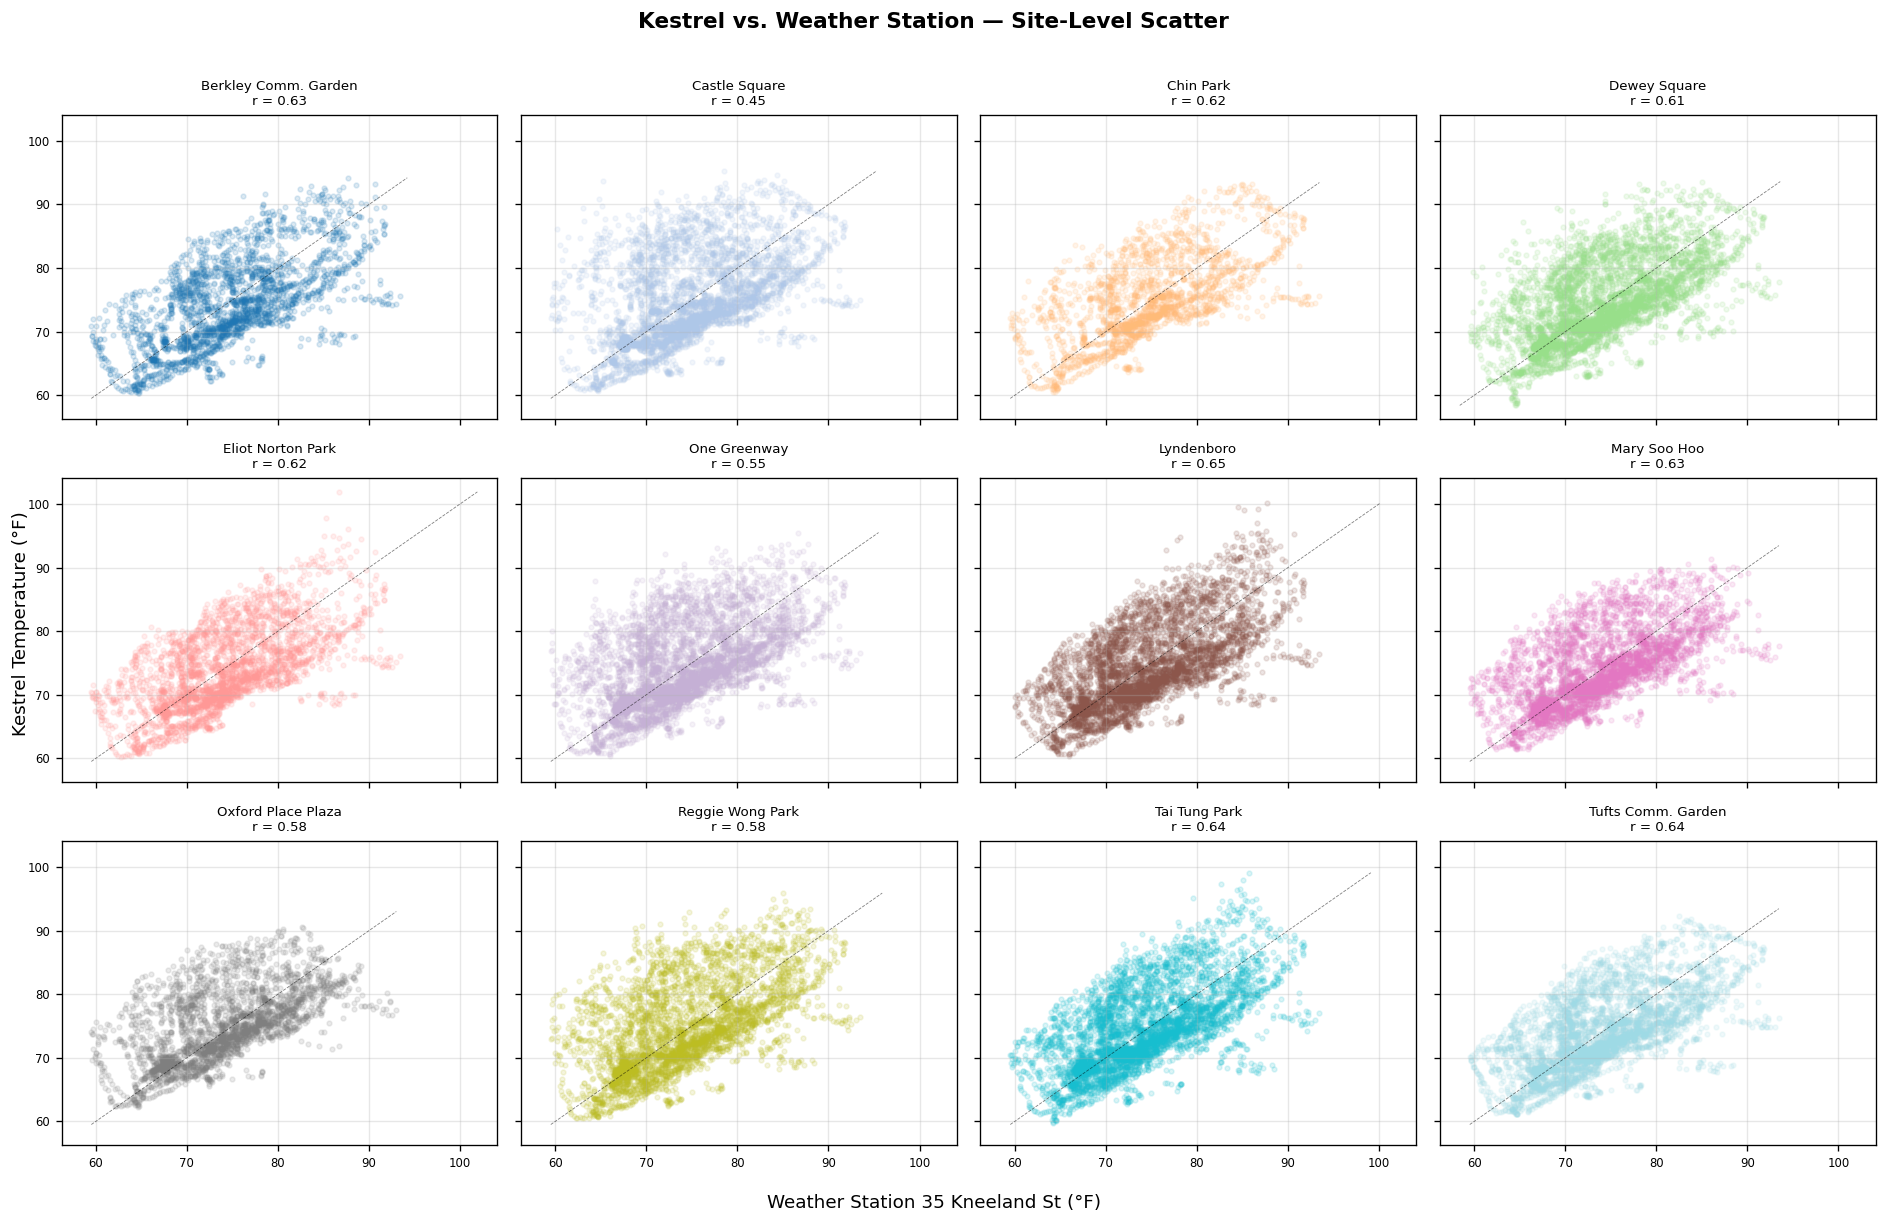

In [17]:
# 12-panel scatter: Kestrel temp (y) vs 35 Kneeland St temp (x)
fig, axes = plt.subplots(3, 4, figsize=(16, 10), sharex=True, sharey=True)
for i, site in enumerate(open_sites):
    ax = axes.flat[i]
    sd = df[df['siteID'] == site][['kes_mean_temp_f', 'mean_temp_out_f']].dropna()

    ax.scatter(sd['mean_temp_out_f'], sd['kes_mean_temp_f'],
              alpha=0.15, s=8, color=site_colors[i])

    r = sd['kes_mean_temp_f'].corr(sd['mean_temp_out_f'])
    ax.set_title(f'{pretty(site)}\nr = {r:.2f}', fontsize=8)

    lims = [min(sd.min()), max(sd.max())]
    ax.plot(lims, lims, 'k--', lw=0.5, alpha=0.5)
    ax.tick_params(labelsize=7)

fig.supxlabel('Weather Station 35 Kneeland St (°F)', fontsize=11)
fig.supylabel('Kestrel Temperature (°F)', fontsize=11)
fig.suptitle('Kestrel vs. Weather Station — Site-Level Scatter',
             fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Interpretation:** The scatter plots show wider spread compared to PM2.5, with correlations of **r = 0.45–0.65** against the 35 Kneeland weather station. This is because the rooftop weather station experiences different wind exposure and radiative effects compared to ground-level open-space sites. Points still cluster around the 1:1 line, but with more scatter.

### 3.6 — Correlation Summary Table

In [18]:
# Correlation: Kestrel vs both reference monitors
temp_corr_rows = []
for site in open_sites:
    sd = df[df['siteID'] == site][[
        'kes_mean_temp_f', 'mean_temp_out_f', 'dep_FEM_nubian_temp_f'
    ]].dropna()
    temp_corr_rows.append({
        'Site': pretty(site),
        'r (vs WS 35 Kneeland)': round(
            sd['kes_mean_temp_f'].corr(sd['mean_temp_out_f']), 3),
        'r (vs DEP Nubian)': round(
            sd['kes_mean_temp_f'].corr(sd['dep_FEM_nubian_temp_f']), 3),
    })

temp_corr_df = pd.DataFrame(temp_corr_rows)
temp_corr_df.style.background_gradient(
    subset=['r (vs WS 35 Kneeland)', 'r (vs DEP Nubian)'],
    cmap='Greens', vmin=0.4, vmax=1.0
)

,Site,r (vs WS 35 Kneeland),r (vs DEP Nubian)
0,Berkley Comm. Garden,0.627000,0.901000
1,Castle Square,0.451000,0.929000
2,Chin Park,0.622000,0.911000
3,Dewey Square,0.606000,0.891000
4,Eliot Norton Park,0.621000,0.900000
5,One Greenway,0.546000,0.920000
6,Lyndenboro,0.652000,0.875000
7,Mary Soo Hoo,0.626000,0.883000
8,Oxford Place Plaza,0.583000,0.892000
9,Reggie Wong Park,0.581000,0.923000


**Key insight:** Kestrel sensors correlate much better with **DEP Nubian (r = 0.88–0.93)** than with 35 Kneeland (r = 0.45–0.65). The 35 Kneeland weather station is a **rooftop installation** with different wind exposure and radiative patterns than ground-level open spaces. The DEP Nubian monitor likely has a sensor setup that better mimics ground-level conditions.

### 3.7 — Diurnal Temperature Pattern

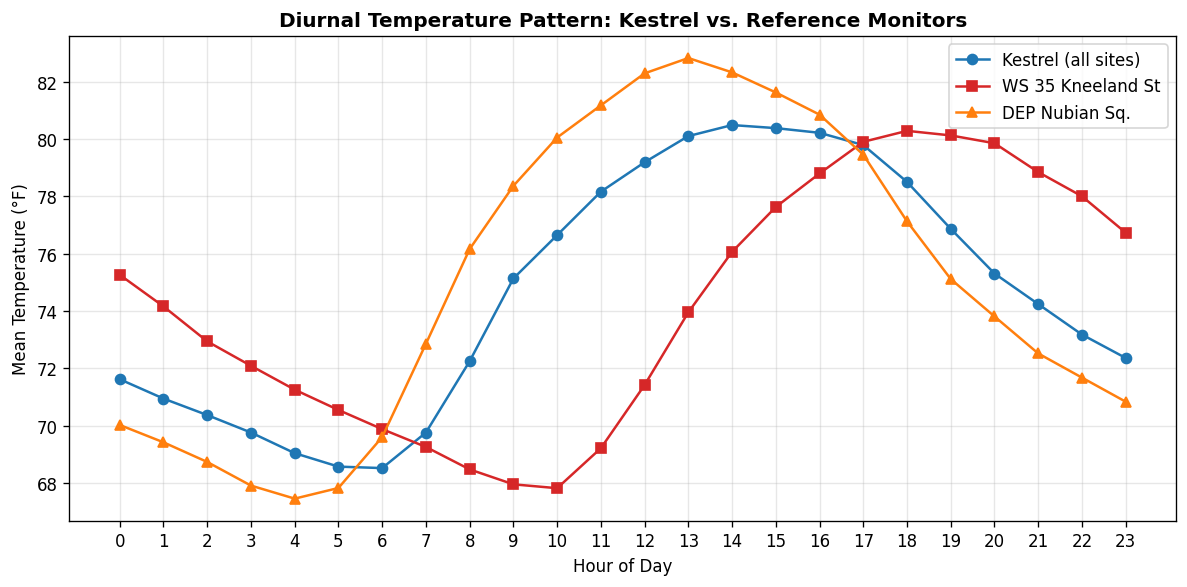

In [19]:
# Average temperature by hour of day
diurnal_temp = df.groupby('hour').agg(
    kes=('kes_mean_temp_f', 'mean'),
    ws=('mean_temp_out_f', 'mean'),
    dep_nu=('dep_FEM_nubian_temp_f', 'mean'),
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(diurnal_temp.index, diurnal_temp['kes'], 'o-',
        label='Kestrel (all sites)', color='#1f77b4')
ax.plot(diurnal_temp.index, diurnal_temp['ws'], 's-',
        label='WS 35 Kneeland St', color='#d62728')
ax.plot(diurnal_temp.index, diurnal_temp['dep_nu'], '^-',
        label='DEP Nubian Sq.', color='#ff7f0e')

ax.set_xlabel('Hour of Day')
ax.set_ylabel('Mean Temperature (°F)')
ax.set_title('Diurnal Temperature Pattern: Kestrel vs. Reference Monitors', fontweight='bold')
ax.legend()
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

**Interpretation:** All three sources show the classic diurnal temperature cycle — peaking in the **afternoon (1–3 PM)** and reaching a minimum in the **early morning (5–6 AM)**. The DEP Nubian monitor runs slightly warmer during daytime, while the 35 Kneeland station shows a wider diurnal range (cooler overnight, warmer during the day), consistent with the more exposed rooftop location.

---

## 4 — Summary & Conclusions

| Metric | Finding |
|---|---|
| **PM2.5 bias** | Purple Air reads +0.7 to +2.7 µg/m³ higher than DEP FEM (11 of 12 sites) |
| **PM2.5 correlation** | r = 0.88–0.96 (excellent temporal agreement with DEP) |
| **Temperature bias** | Kestrel within ±1.4°F of both references |
| **Temp correlation (vs WS 35Kn)** | r = 0.45–0.65 (moderate; rooftop vs. ground-level) |
| **Temp correlation (vs DEP Nubian)** | r = 0.88–0.93 (strong agreement) |
| **Hottest site** | Castle Square (75.3°F mean) |
| **Highest PM2.5** | One Greenway (10.76 µg/m³ mean) |
| **Lowest PM2.5** | Castle Square (7.90 µg/m³ mean) |

### Implications

1. **Purple Air sensors are reliable for tracking PM2.5 trends** — correlations with DEP FEM exceed r = 0.88 at all sites. However, a site-specific correction factor (~1–3 µg/m³) should be applied when comparing absolute concentrations to regulatory data.

2. **Kestrel temperature sensors perform comparably** to reference instruments (within ±1.4°F), making them suitable for micro-scale heat exposure studies in urban open spaces.

3. **PM2.5 varies more across sites than temperature**, suggesting that local emission and dispersion factors (traffic, building canyoning, vegetation) influence air quality more than temperature at the neighborhood scale.